In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [2]:
model_path = "../models/best_yolo8s_ball-detection.pt"
model = YOLO(model_path)

In [3]:
video_path = "../input_video/input_1.mp4"

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
num_samples = 10  # ganti jadi 5 kalau mau lebih sedikit

# Ambil frame secara merata
frame_indices = np.linspace(0, total_frames - 1, num_samples, dtype=int)

frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

cap.release()

print(f"Berhasil ambil {len(frames)} frame")

Berhasil ambil 10 frame


In [4]:
results = model(frames, imgsz=1280, conf=0.25)


0: 800x1280 (no detections), 941.8ms
1: 800x1280 (no detections), 941.8ms
2: 800x1280 (no detections), 941.8ms
3: 800x1280 1 ball, 941.8ms
4: 800x1280 1 ball, 941.8ms
5: 800x1280 1 ball, 941.8ms
6: 800x1280 (no detections), 941.8ms
7: 800x1280 1 ball, 941.8ms
8: 800x1280 (no detections), 941.8ms
9: 800x1280 1 ball, 941.8ms
Speed: 25.9ms preprocess, 941.8ms inference, 3.2ms postprocess per image at shape (1, 3, 800, 1280)


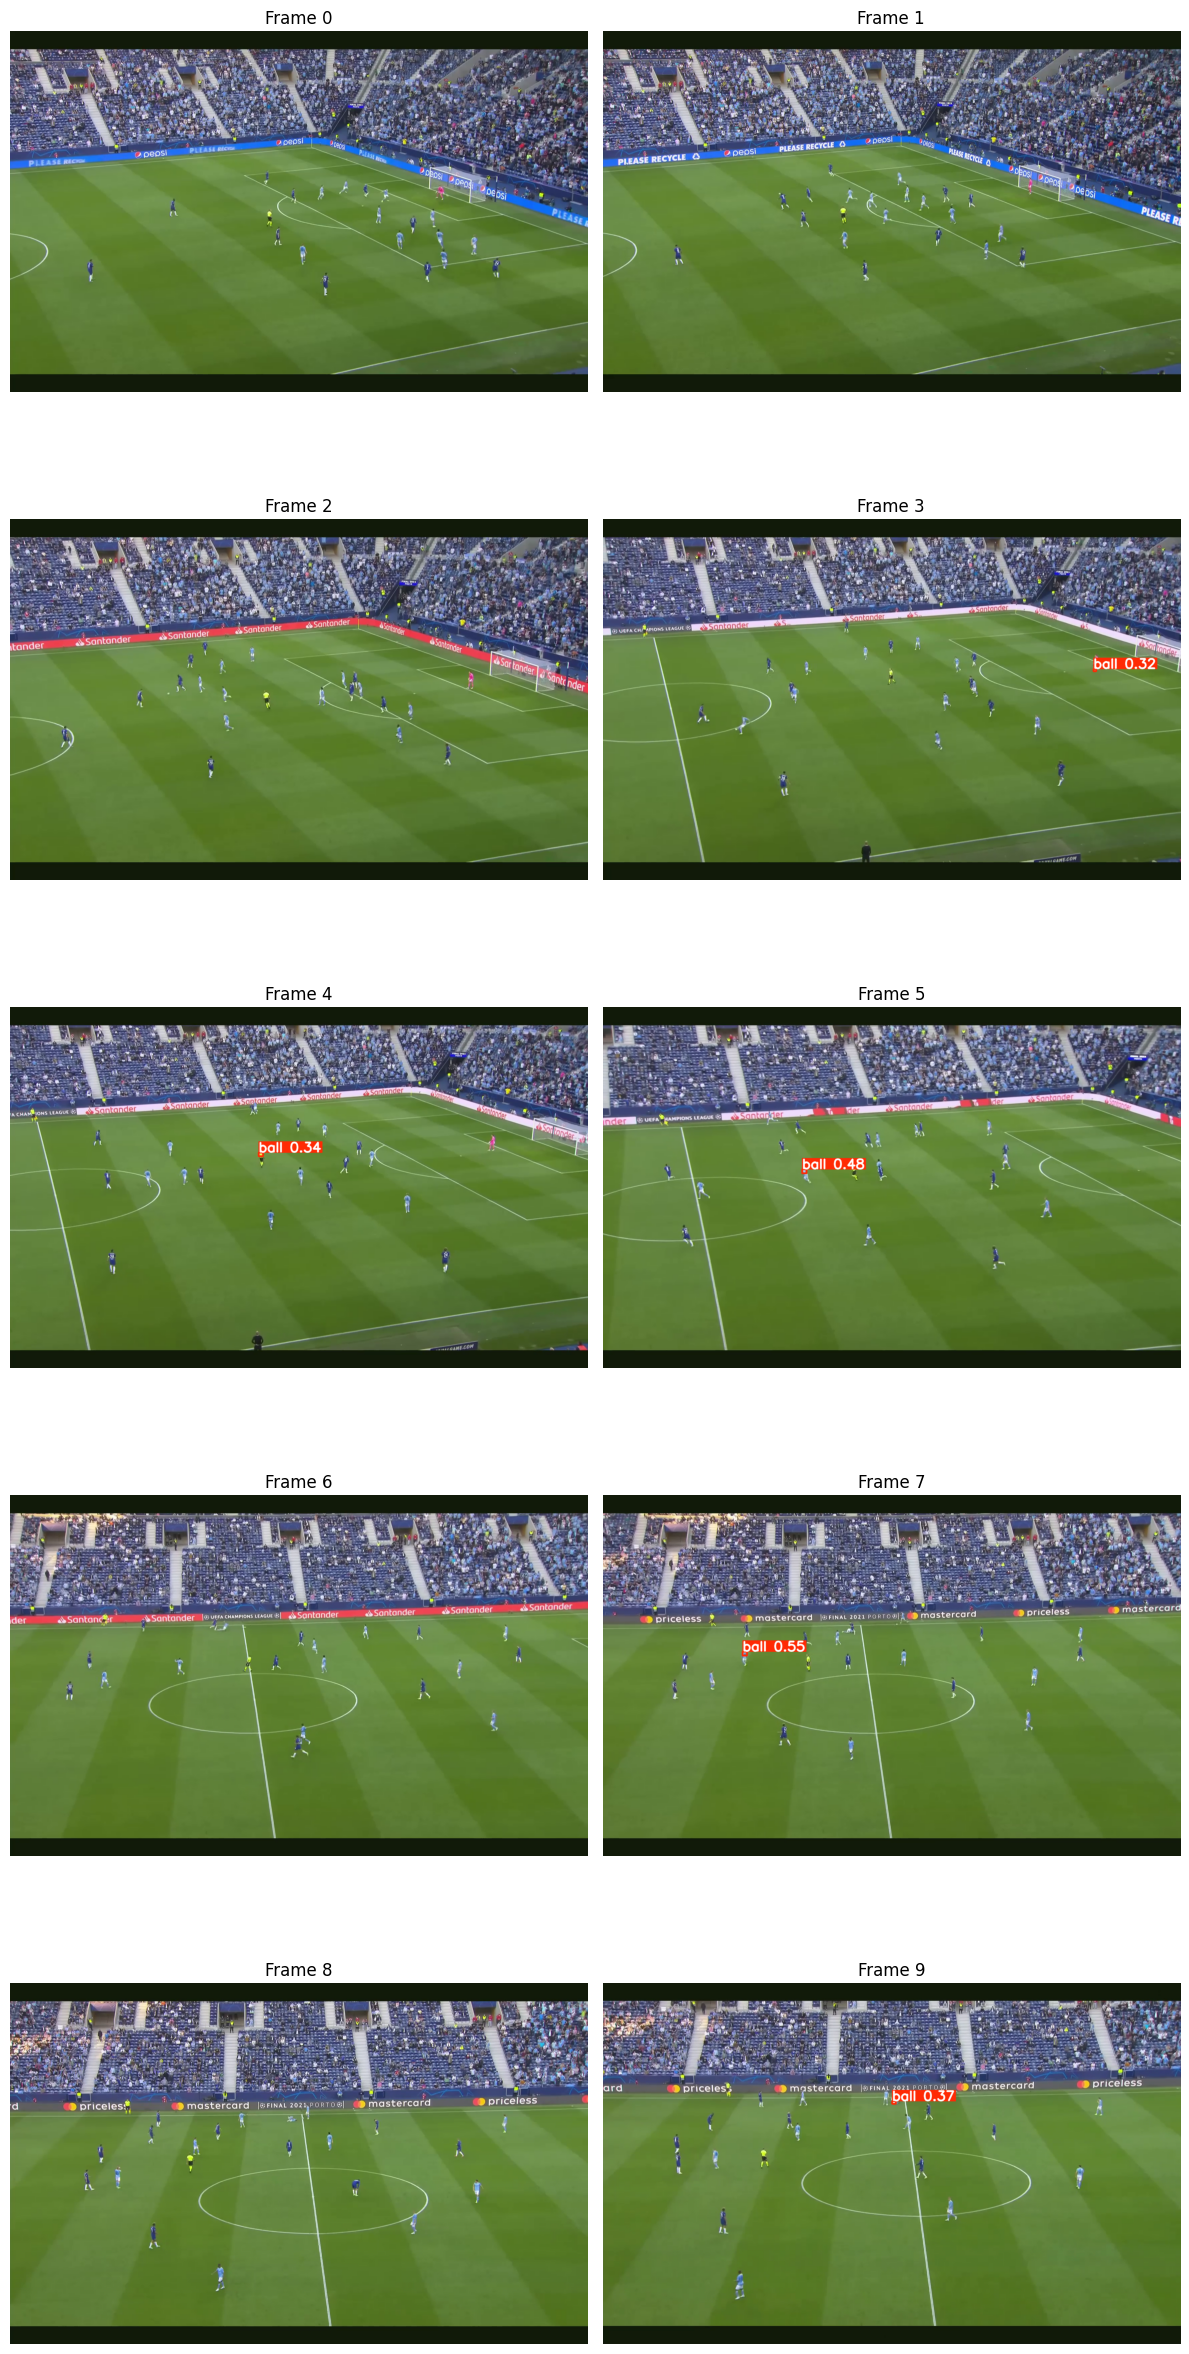

In [6]:
num_frames = len(results)

cols = 2 
rows = (num_frames + cols - 1) // cols

plt.figure(figsize=(12, rows * 5))  # tinggi otomatis ikut jumlah row

for i, result in enumerate(results):
    annotated = result.plot()
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(annotated)
    plt.title(f"Frame {i}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
for i, result in enumerate(results):
    print(f"Frame {i}")
    for box in result.boxes:
        print("  Conf:", float(box.conf))
        print("  Class:", int(box.cls))
        print("  BBox:", box.xyxy.tolist())
    print("------")

Frame 0
------
Frame 1
------
Frame 2
------
Frame 3
  Conf: 0.3205455541610718
  Class: 0
  BBox: [[1466.94873046875, 448.1888122558594, 1474.611083984375, 455.947509765625]]
------
Frame 4
  Conf: 0.3411172926425934
  Class: 0
  BBox: [[743.4691772460938, 435.55670166015625, 756.0126953125, 446.0884094238281]]
------
Frame 5
  Conf: 0.4802316725254059
  Class: 0
  BBox: [[595.9395751953125, 485.88787841796875, 608.118408203125, 497.12481689453125]]
------
Frame 6
------
Frame 7
  Conf: 0.5531557202339172
  Class: 0
  BBox: [[417.0546875, 468.53204345703125, 430.2854919433594, 480.01947021484375]]
------
Frame 8
------
Frame 9
  Conf: 0.37451550364494324
  Class: 0
  BBox: [[864.3641967773438, 353.4222412109375, 875.0399780273438, 361.8722839355469]]
------
